# 01 - Analise exploratoria: quem sao os alunos de Hogwarts?

Antes de sair treinando modelo, precisei entender o dataset que escolhi no Kaggle
([Harry Potter Sorting Dataset](https://www.kaggle.com/datasets/sahityapalacharla/harry-potter-sorting-dataset)).

Sao 1000 estudantes ficticios com notas de 0 a 10 em oito atributos, o status de
sangue e a casa em que cada um foi colocado. A ideia do projeto e substituir o
Chapeu Seletor por um modelo de classificacao, entao aqui eu quero responder:

1. Os dados estao limpos? (nulos, duplicados, tipos)
2. As classes estao balanceadas?
3. Quais atributos realmente separam as casas?
4. Tem alguma variavel que nao serve pra nada (ou que eu nao *deveria* usar)?

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 20)
sns.set_theme(style="whitegrid")

# Paleta com as cores das casas, so pra ficar mais facil de ler os graficos
CORES_CASAS = {
    "Gryffindor": "#7F0909",
    "Slytherin": "#0D6217",
    "Ravenclaw": "#222F5B",
    "Hufflepuff": "#D3A625",
}

df = pd.read_csv("../data/harry_potter_1000_students.csv")
df.head()

,Blood Status,Bravery,Intelligence,Loyalty,Ambition,Dark Arts Knowledge,Quidditch Skills,Dueling Skills,Creativity,House
0,Half-blood,9,4,7,5,0,8,8,7,Gryffindor
1,Muggle-born,6,8,5,7,5,6,4,9,Ravenclaw
2,Pure-blood,1,4,7,7,1,4,4,6,Hufflepuff
3,Pure-blood,9,1,3,4,1,9,10,1,Gryffindor
4,Muggle-born,5,9,7,3,3,6,7,9,Ravenclaw


In [2]:
print("Formato:", df.shape)
df.info()

Formato: (1000, 10)
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Blood Status         1000 non-null   str  
 1   Bravery              1000 non-null   int64
 2   Intelligence         1000 non-null   int64
 3   Loyalty              1000 non-null   int64
 4   Ambition             1000 non-null   int64
 5   Dark Arts Knowledge  1000 non-null   int64
 6   Quidditch Skills     1000 non-null   int64
 7   Dueling Skills       1000 non-null   int64
 8   Creativity           1000 non-null   int64
 9   House                1000 non-null   str  
dtypes: int64(8), str(2)
memory usage: 78.3 KB


## Qualidade dos dados

Primeira checagem obrigatoria: valores faltantes, duplicados e se os intervalos
fazem sentido.

In [3]:
print("Valores nulos por coluna:")
print(df.isna().sum())
print("\nLinhas duplicadas:", df.duplicated().sum())

Valores nulos por coluna:
Blood Status           0
Bravery                0
Intelligence           0
Loyalty                0
Ambition               0
Dark Arts Knowledge    0
Quidditch Skills       0
Dueling Skills         0
Creativity             0
House                  0
dtype: int64

Linhas duplicadas: 0


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Bravery,1000.0,5.026,2.682633,1.0,3.0,5.0,7.0,10.0
Intelligence,1000.0,5.281,2.661790,1.0,3.0,5.0,7.0,10.0
Loyalty,1000.0,5.129,2.695111,1.0,3.0,5.0,7.0,10.0
Ambition,1000.0,5.136,2.716041,1.0,3.0,5.0,7.0,10.0
Dark Arts Knowledge,1000.0,4.040,3.112248,0.0,1.0,3.0,7.0,10.0
Quidditch Skills,1000.0,5.460,2.748810,0.0,4.0,6.0,7.0,10.0
Dueling Skills,1000.0,6.223,2.833249,1.0,4.0,7.0,9.0,10.0
Creativity,1000.0,5.208,2.730969,1.0,3.0,5.0,7.0,10.0


Nenhum nulo, nenhum duplicado e todas as notas dentro do intervalo esperado.
Chama atencao que `Dark Arts Knowledge` comeca em 0 e tem media bem mais baixa
(4.04) que os outros atributos - faz sentido, a maioria dos alunos nao manja de
artes das trevas.

## A variavel-alvo: as quatro casas

House
Slytherin     265
Ravenclaw     258
Hufflepuff    251
Gryffindor    226
Name: count, dtype: int64

Proporcao:
House
Slytherin     26.5
Ravenclaw     25.8
Hufflepuff    25.1
Gryffindor    22.6
Name: count, dtype: float64


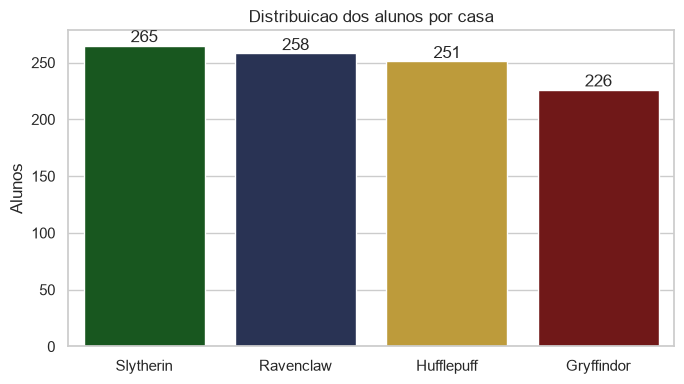

In [5]:
contagem = df["House"].value_counts()
print(contagem)
print("\nProporcao:")
print((contagem / len(df) * 100).round(1))

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(x=contagem.index, y=contagem.values,
            hue=contagem.index, palette=CORES_CASAS, legend=False, ax=ax)
ax.set_title("Distribuicao dos alunos por casa")
ax.set_xlabel("")
ax.set_ylabel("Alunos")
for i, v in enumerate(contagem.values):
    ax.text(i, v + 3, str(v), ha="center")
plt.tight_layout()
plt.savefig("figuras/distribuicao_casas.png", dpi=120)
plt.show()

Dataset bem balanceado (de 22.6% a 26.5% por casa). Isso e bom porque nao vou
precisar de tecnicas de balanceamento, e a acuracia ja vira uma metrica honesta.
A baseline de "chutar sempre a classe majoritaria" seria **26.5%**.

## Os atributos separam as casas?

In [6]:
atributos = [c for c in df.columns if c not in ("House", "Blood Status")]
medias = df.groupby("House")[atributos].mean()
medias.round(2)

,Bravery,Intelligence,Loyalty,Ambition,Dark Arts Knowledge,Quidditch Skills,Dueling Skills,Creativity
House,,,,,,,,
Gryffindor,8.62,4.32,3.98,3.88,2.19,7.46,8.76,4.08
Hufflepuff,3.84,4.17,8.51,4.01,2.47,3.67,3.86,4.03
Ravenclaw,4.12,8.55,3.92,3.84,2.57,3.60,4.02,8.64
Slytherin,3.96,3.97,4.08,8.53,8.53,7.25,8.44,3.95


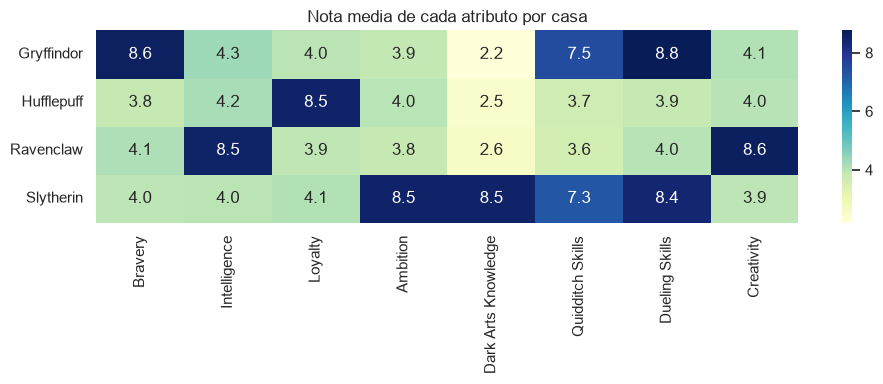

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(medias, annot=True, fmt=".1f", cmap="YlGnBu", ax=ax)
ax.set_title("Nota media de cada atributo por casa")
ax.set_ylabel("")
ax.tick_params(axis="y", rotation=0)
plt.tight_layout()
plt.savefig("figuras/media_atributos_por_casa.png", dpi=120)
plt.show()

Esse heatmap resolveu metade do problema. Da pra ver o padrao na cara:

| Casa | Atributo dominante | Media |
|---|---|---|
| Gryffindor | Bravery | 8.6 |
| Ravenclaw | Intelligence | 8.6 |
| Hufflepuff | Loyalty | 8.5 |
| Slytherin | Ambition | 8.5 |

E tem atributos secundarios que ajudam a desempatar:
- `Dark Arts Knowledge` e praticamente exclusivo da Slytherin (8.5 contra ~2.4 nas outras).
- `Creativity` acompanha a Ravenclaw (8.6).
- `Dueling Skills` e `Quidditch Skills` sobem em Gryffindor **e** Slytherin.

Ou seja: existe sinal de sobra. O desafio vai ser mais nos casos de empate.

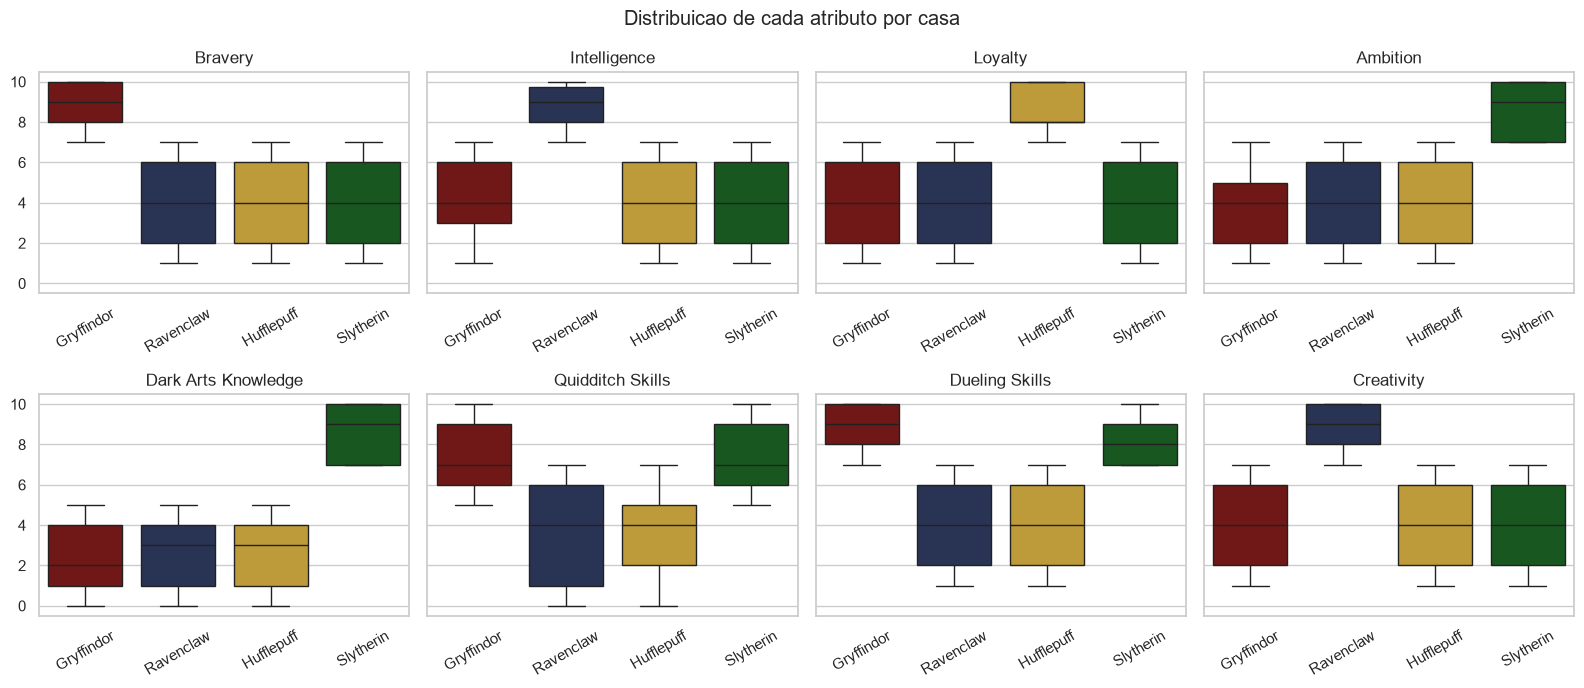

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharey=True)
for ax, coluna in zip(axes.flat, atributos):
    sns.boxplot(data=df, x="House", y=coluna, hue="House",
                palette=CORES_CASAS, legend=False, ax=ax)
    ax.set_title(coluna)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=30)
plt.suptitle("Distribuicao de cada atributo por casa")
plt.tight_layout()
plt.savefig("figuras/boxplots_atributos.png", dpi=120)
plt.show()

## E o status de sangue?

Essa e a variavel que eu mais queria olhar, porque no universo do Harry Potter
ela e justamente o criterio preconceituoso que a Slytherin usa. Sera que o
dataset carrega esse vies?

In [9]:
tabela = pd.crosstab(df["Blood Status"], df["House"], normalize="index") * 100
tabela.round(1)

House,Gryffindor,Hufflepuff,Ravenclaw,Slytherin
Blood Status,,,,
Half-blood,24.2,24.8,26.8,24.2
Muggle-born,19.8,23.6,27.5,29.1
Pure-blood,23.5,26.8,23.2,26.5


In [10]:
from scipy.stats import chi2_contingency

chi2, p, gl, _ = chi2_contingency(pd.crosstab(df["Blood Status"], df["House"]))
print(f"Qui-quadrado = {chi2:.3f} | graus de liberdade = {gl} | p-valor = {p:.4f}")

Qui-quadrado = 5.094 | graus de liberdade = 6 | p-valor = 0.5318


p-valor bem acima de 0.05, ou seja: **nao da pra rejeitar a hipotese de que status
de sangue e casa sao independentes**. Cada linha da tabela fica perto de 25% em
todas as casas.

Isso me deu a decisao mais facil do projeto: vou **descartar `Blood Status` do
modelo**. Ela nao agrega informacao nenhuma e, se agregasse, seria um atributo
discriminatorio que nao deveria entrar num sistema que decide o destino de um
aluno. Vou confirmar isso no notebook 02 treinando com e sem a variavel.

## Correlacao entre os atributos

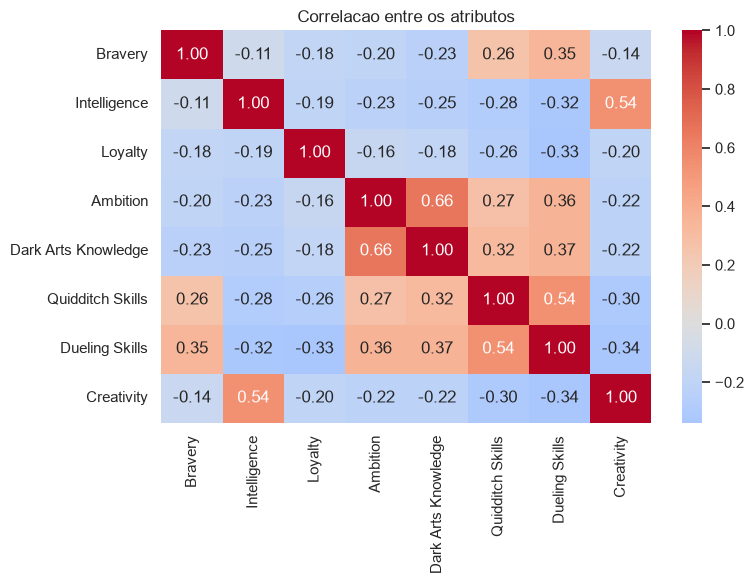

In [11]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(df[atributos].corr(), annot=True, fmt=".2f", cmap="coolwarm",
            center=0, ax=ax)
ax.set_title("Correlacao entre os atributos")
ax.tick_params(axis="y", rotation=0)
plt.tight_layout()
plt.savefig("figuras/correlacao_atributos.png", dpi=120)
plt.show()

Correlacoes baixas no geral (nada acima de 0.35), entao nao tenho problema de
multicolinearidade forte. A maior e entre `Quidditch Skills` e `Dueling Skills`,
o que faz sentido - as duas sobem juntas em Gryffindor e Slytherin.

## Baseline: a regra do chapeu "analogico"

Antes de treinar qualquer modelo, montei a regra mais obvia possivel: manda o
aluno para a casa do atributo em que ele foi melhor entre os quatro tracos
classicos. Se um modelo de ML nao ganhar disso, nao vale a pena.

In [12]:
REGRA = {
    "Bravery": "Gryffindor",
    "Intelligence": "Ravenclaw",
    "Loyalty": "Hufflepuff",
    "Ambition": "Slytherin",
}

palpite = df[list(REGRA)].idxmax(axis=1).map(REGRA)
acerto_regra = (palpite == df["House"]).mean()
print(f"Acuracia da regra do maior atributo: {acerto_regra * 100:.2f}%")
print(f"Acuracia de chutar a classe majoritaria: {contagem.max() / len(df) * 100:.2f}%")

Acuracia da regra do maior atributo: 94.60%
Acuracia de chutar a classe majoritaria: 26.50%


## Conclusoes desta etapa

- Dataset limpo: 1000 linhas, sem nulos, sem duplicados, classes balanceadas.
- Oito atributos numericos de 0 a 10 com sinal forte; quatro deles (Bravery,
  Intelligence, Loyalty, Ambition) praticamente definem a casa.
- `Blood Status` e estatisticamente independente da casa -> sai do modelo.
- **Baselines para bater:** 26.5% (classe majoritaria) e 94.6% (regra do maior
  atributo). O alvo do notebook 02 e passar dos 94.6%, principalmente nos empates.